In [5]:
import numpy as np
import matplotlib.pyplot as plt


In [40]:
def softmax(tensor:np.ndarray) -> np.ndarray:
    numerator = np.exp(tensor)
    denominator = np.exp(tensor).sum()
    return numerator / denominator

In [41]:
np.random.seed(42)
sigma, mu = 1.5, 0
embedding_size = 8
sequence_length = 12

embeddings = sigma * np.random.randn(embedding_size, sequence_length) + mu
embeddings

array([[ 0.7451, -0.2074,  0.9715,  2.2845, -0.3512, -0.3512,  2.3688,
         1.1512, -0.7042,  0.8138, -0.6951, -0.6986],
       [ 0.3629, -2.8699, -2.5874, -0.8434, -1.5192,  0.4714, -1.362 ,
        -2.1185,  2.1985, -0.3387,  0.1013, -2.1371],
       [-0.8166,  0.1664, -1.7265,  0.5635, -0.901 , -0.4375, -0.9026,
         2.7784, -0.0202, -1.5866,  1.2338, -1.8313],
       [ 0.3133, -2.9395, -1.9923,  0.2953,  1.1077,  0.2571, -0.1735,
        -0.4517, -2.2178, -1.0798, -0.691 ,  1.5857],
       [ 0.5154, -2.6446,  0.4861, -0.5776, -1.0154,  0.9175,  1.5465,
         1.3969, -1.2588, -0.4638,  0.4969,  1.4633],
       [-0.7188, -0.2785, -1.6595, -1.7943,  1.2188,  2.0344, -0.108 ,
         1.5053,  0.5425, -0.9677,  0.5421,  2.3071],
       [-0.0537,  2.347 , -3.9296,  1.2329,  0.1306, -0.4485,  0.1376,
        -2.9814, -0.3295,  0.5357,  2.2168, -0.7774],
       [-1.2127, -0.7526,  1.3731,  0.4931, -0.7946,  0.7699,  0.1456,
         1.453 , -1.0531, -0.4915, -0.5882, -2.1953]])


Attention(Q,K,V) = softmax(QK^T / k_m) V


Dot Product

In [42]:
Q = K = V = np.copy(embeddings)

d_k = K.size

dot_product = Q @ K.T

np.set_printoptions(precision=4, suppress=True)
print(f'Input shape, {np.shape(Q)}, Dot product shape, {np.shape(dot_product)}: \n{dot_product}')

Input shape, (8, 12), Dot product shape, (8, 8): 
[[ 16.0738  -9.2732  -0.3576  -1.7725   4.5324  -9.0129  -4.8522   6.0234]
 [ -9.2732  34.1729   4.2552   5.1181  -1.7718  -0.9442   9.0712  -1.4718]
 [ -0.3576   4.2552  20.9237  -1.3459  -0.3322   2.6545   2.9001   7.1525]
 [ -1.7725   5.1181  -1.3459  23.3986  10.2777   7.7071   0.0171  -2.3298]
 [  4.5324  -1.7718  -0.3322  10.2777  18.2332   6.5718 -13.2225   3.5651]
 [ -9.0129  -0.9442   2.6545   7.7071   6.5718  21.3164  -2.8508  -4.7921]
 [ -4.8522   9.0712   2.9001   0.0171 -13.2225  -2.8508  37.5128 -10.7634]
 [  6.0234  -1.4718   7.1525  -2.3298   3.5651  -4.7921 -10.7634  14.038 ]]


In [46]:

dot_prod_softmax = softmax(dot_product / np.sqrt(d_k))
dot_prod_softmax.shape, dot_prod_softmax

((8, 8),
 array([[0.0271, 0.002 , 0.0051, 0.0044, 0.0084, 0.0021, 0.0032, 0.0097],
        [0.002 , 0.172 , 0.0081, 0.0089, 0.0044, 0.0048, 0.0133, 0.0045],
        [0.0051, 0.0081, 0.0445, 0.0046, 0.0051, 0.0069, 0.0071, 0.0109],
        [0.0044, 0.0089, 0.0046, 0.0573, 0.015 , 0.0115, 0.0053, 0.0041],
        [0.0084, 0.0044, 0.0051, 0.015 , 0.0338, 0.0103, 0.0014, 0.0076],
        [0.0021, 0.0048, 0.0069, 0.0115, 0.0103, 0.0463, 0.0039, 0.0032],
        [0.0032, 0.0133, 0.0071, 0.0053, 0.0014, 0.0039, 0.2419, 0.0018],
        [0.0097, 0.0045, 0.0109, 0.0041, 0.0076, 0.0032, 0.0018, 0.022 ]]))

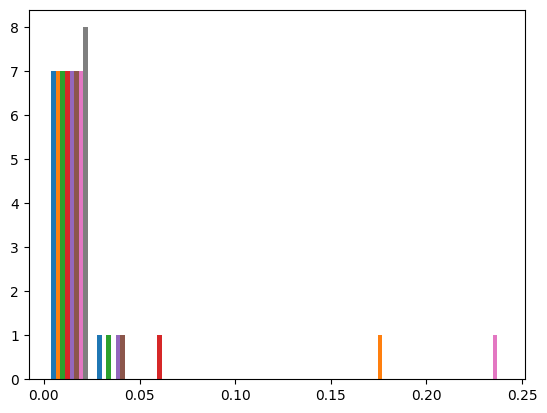

In [45]:
outputs = plt.hist(dot_prod_softmax)

In [49]:
attention = dot_prod_softmax @ V
attention.shape, attention

((8, 12),
 array([[ 0.009 , -0.046 ,  0.0049,  0.0646, -0.0256,  0.0083,  0.0707,
          0.0584, -0.0451, -0.0004, -0.0088, -0.0324],
        [ 0.0527, -0.5041, -0.5266, -0.1258, -0.2601,  0.0904, -0.2296,
         -0.3632,  0.3449, -0.0808,  0.0514, -0.3727],
        [-0.0441, -0.0374, -0.1238,  0.03  , -0.0536,  0.0077, -0.0303,
          0.1225, -0.0133, -0.0848,  0.0646, -0.1012],
        [ 0.0148, -0.2277, -0.1676,  0.0012,  0.0405,  0.0535,  0.0075,
          0.0018, -0.1295, -0.0859, -0.0131,  0.0958],
        [ 0.0092, -0.1524, -0.0375, -0.0099, -0.0252,  0.0579,  0.0591,
          0.0773, -0.075 , -0.0476,  0.0115,  0.0548],
        [-0.0308, -0.0802, -0.1281, -0.0746,  0.0425,  0.1059,  0.0021,
          0.0833, -0.0092, -0.0724,  0.0366,  0.1058],
        [-0.0142,  0.5087, -1.008 ,  0.2929,  0.0118, -0.0945,  0.0175,
         -0.718 , -0.066 ,  0.1055,  0.5423, -0.2161],
        [-0.024 , -0.0588, -0.0077,  0.0286, -0.0366,  0.0247,  0.0211,
          0.0723, -0.0379, -0

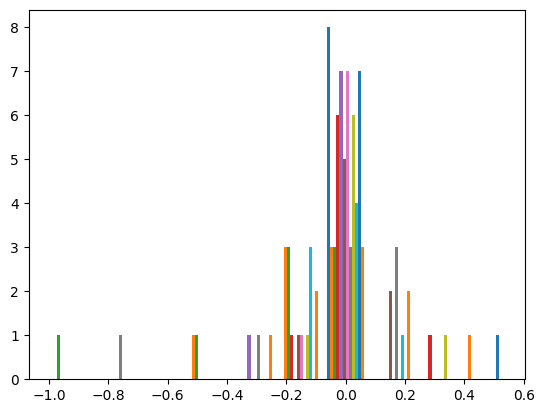

In [50]:
o = plt.hist(attention)

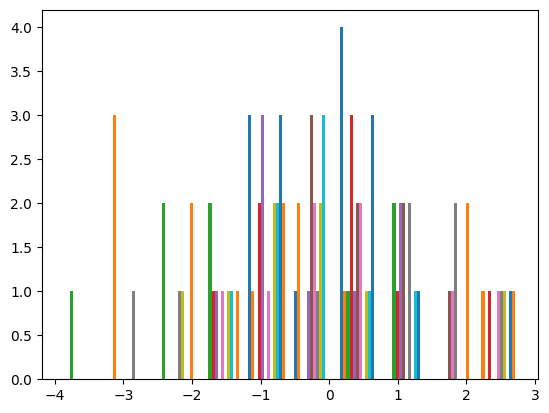

In [51]:
o = plt.hist(V)